<a href="https://colab.research.google.com/github/lamini-H/ML_Projects/blob/main/Lithology_Prediction_Logs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Understanding the Dataset

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#Load the dataset
file_path = "/content/CSV_train_reduced.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,9/13/2015,494.528,437641.9688,6470972.5,-469.501831,NORDLAND GP.,NaN,19.480835,NaN,1.611410,...,34.636410,NaN,NaN,-0.574928,NaN,NaN,NaN,NaN,65000.0,1.0
1,9/13/2015,494.680,437641.9688,6470972.5,-469.653809,NORDLAND GP.,NaN,19.468800,NaN,1.618070,...,34.636410,NaN,NaN,-0.570188,NaN,NaN,NaN,NaN,65000.0,1.0
2,9/13/2015,494.832,437641.9688,6470972.5,-469.805786,NORDLAND GP.,NaN,19.468800,NaN,1.626459,...,34.779556,NaN,NaN,-0.574245,NaN,NaN,NaN,NaN,65000.0,1.0
3,9/13/2015,494.984,437641.9688,6470972.5,-469.957794,NORDLAND GP.,NaN,19.459282,NaN,1.621594,...,39.965164,NaN,NaN,-0.586315,NaN,NaN,NaN,NaN,65000.0,1.0
4,9/13/2015,495.136,437641.9688,6470972.5,-470.109772,NORDLAND GP.,NaN,19.453100,NaN,1.602679,...,57.483765,NaN,NaN,-0.597914,NaN,NaN,NaN,NaN,65000.0,1.0


In [ ]:
df.shape

(117898, 29)

In [ ]:
#checking the missing values
df.isnull().sum()

,0
WELL,0
DEPTH_MD,0
X_LOC,7384
Y_LOC,7384
Z_LOC,7384
GROUP,1
FORMATION,20588
CALI,193
RSHA,55859
RMED,7582


## Handling Missing Values
 1. Features with Too Many Missing Values shall be drop Since these features will not be useful for the model `eg. SGR,DTS,RMIC, ROPA,RXO,BS, ROP, PEF`
 2. Features with missing values approximately 10-15% will be impute with mean or median
  *Geospatial Data `X_LOC,Y_LOC,Z_LOC` impute with mean*

  *Logging Features `RMED,RDEP,RHOB,DTC,SP,DRHO,NUDWEIGHT` impute with median values per wall*.

3. Categorical Data Handling
   Missing values eg `Group and Formation` will be impute with most frequently value.


In [ ]:
#Drop features with over 90% missing values
columns_to_drop = ['SGR', 'DTS','RMIC','ROPA','RXO','BS','ROP','PEF' ]
df_cleaned = df.drop(columns=columns_to_drop)

In [ ]:
#Impute missing geospatial data (X_LOC, Y_LOC,Z_LOC) using mean
for col in ['X_LOC', 'Y_LOC', 'Z_LOC']:
    df_cleaned.fillna({col: df_cleaned[col].mean()}, inplace=True)

In [ ]:
#Impute missing well log data using median
log_features = ['RMED', 'RDEP', 'RHOB', 'DTC', 'SP', 'DRHO','MUDWEIGHT']
for col in log_features:
  if col in df_cleaned.columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())
    df_cleaned.fillna({col: df_cleaned[col].median()}, inplace=True)

In [ ]:
#Handling categorical variables with missing values
df_cleaned['GROUP'].fillna("Missing", inplace=True)
df_cleaned['FORMATION'].fillna("Missing", inplace=True)

<ipython-input-9-a2b0029f601a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['GROUP'].fillna("Missing", inplace=True)
<ipython-input-9-a2b0029f601a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
missing_values_after=df_cleaned.isnull().sum()
missing_values_after

,0
WELL,0
DEPTH_MD,0
X_LOC,0
Y_LOC,0
Z_LOC,0
GROUP,0
FORMATION,0
CALI,193
RSHA,55859
RMED,0


In [ ]:
# Droping the highly missing features `RSHA,DCAL,NPHI,CALI`
df_cleaned = df_cleaned.drop(columns=['RSHA', 'DCAL', 'NPHI', 'CALI'])

In [ ]:
#Impute `FORCE_2020_LITHOFACIES_CONFIDENCE` with mode
df_cleaned['FORCE_2020_LITHOFACIES_CONFIDENCE'] = df_cleaned['FORCE_2020_LITHOFACIES_CONFIDENCE'].fillna(df_cleaned['FORCE_2020_LITHOFACIES_CONFIDENCE'].mode()[0])

In [ ]:
missing_values_final=df_cleaned.isnull().sum()
missing_values_final

,0
WELL,0
DEPTH_MD,0
X_LOC,0
Y_LOC,0
Z_LOC,0
GROUP,0
FORMATION,0
RMED,0
RDEP,0
RHOB,0


In [ ]:
#Saving the cleaned dataset to csv
df_cleaned.to_csv('cleaned_dataset.csv', index=False)

In [ ]:
df_cleaned.shape

(117898, 17)

In [ ]:
df_cleaned.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,9/13/2015,494.528,437641.9688,6470972.5,-469.501831,NORDLAND GP.,Missing,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0
1,9/13/2015,494.680,437641.9688,6470972.5,-469.653809,NORDLAND GP.,Missing,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0
2,9/13/2015,494.832,437641.9688,6470972.5,-469.805786,NORDLAND GP.,Missing,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0
3,9/13/2015,494.984,437641.9688,6470972.5,-469.957794,NORDLAND GP.,Missing,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0
4,9/13/2015,495.136,437641.9688,6470972.5,-470.109772,NORDLAND GP.,Missing,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0


In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117898 entries, 0 to 117897
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   WELL                               117898 non-null  object 
 1   DEPTH_MD                           117898 non-null  float64
 2   X_LOC                              117898 non-null  float64
 3   Y_LOC                              117898 non-null  float64
 4   Z_LOC                              117898 non-null  float64
 5   GROUP                              117898 non-null  object 
 6   FORMATION                          117898 non-null  object 
 7   RMED                               117898 non-null  float64
 8   RDEP                               117898 non-null  float64
 9   RHOB                               117898 non-null  float64
 10  GR                                 117897 non-null  float64
 11  DTC                                1178

## Exploratory Data Analysis (EDA) Plan

* Summary Statistics
* Distribution of the Target Variable `FORCE_2020_LITHOFACIES_LITHOLOGY`
* Feature Distributions
* Correlation Analysis
* Feature Relationships

In [ ]:
#Summary Statistics
summary_stats = df_cleaned.describe()
summary_stats

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
count,117898.000000,117898.000000,1.178980e+05,117898.000000,117898.000000,117898.000000,117898.000000,117897.000000,117898.000000,117898.000000,117898.000000,117898.000000,117897.000000,117898.000000
mean,1814.915941,447761.232097,6.464389e+06,-1746.447407,1.575997,1.565949,2.184049,68.745470,123.392319,87.228212,0.008578,1.996449,63104.514008,1.241022
std,766.096243,12515.123998,2.535687e+04,747.658356,6.435031,11.174397,0.218211,39.926477,34.738487,88.473682,0.063148,16.620406,13434.765123,0.483027
min,415.261599,436790.843800,6.429286e+06,-3246.156250,-0.008419,0.123068,1.366913,0.109284,7.415132,-2.199269,-1.795894,0.125818,30000.000000,1.000000
25%,1171.992000,437640.031300,6.444988e+06,-2394.222473,0.790804,0.787507,2.045044,42.471733,87.889347,51.640265,-0.004400,0.140197,65000.000000,1.000000
50%,1762.178999,444151.500000,6.463012e+06,-1734.176941,1.083847,1.119053,2.153269,64.868698,136.423294,70.282761,0.003772,0.152180,65000.000000,1.000000
75%,2510.745898,459500.687500,6.470984e+06,-1141.498321,1.434103,1.573545,2.340450,92.639694,147.925667,88.330723,0.015909,0.167757,65000.000000,1.000000
max,3272.024000,475436.281300,6.539631e+06,-1.000000,1796.209106,1856.935059,3.115611,804.298950,230.432953,526.547302,0.323460,185.730927,99000.000000,3.000000


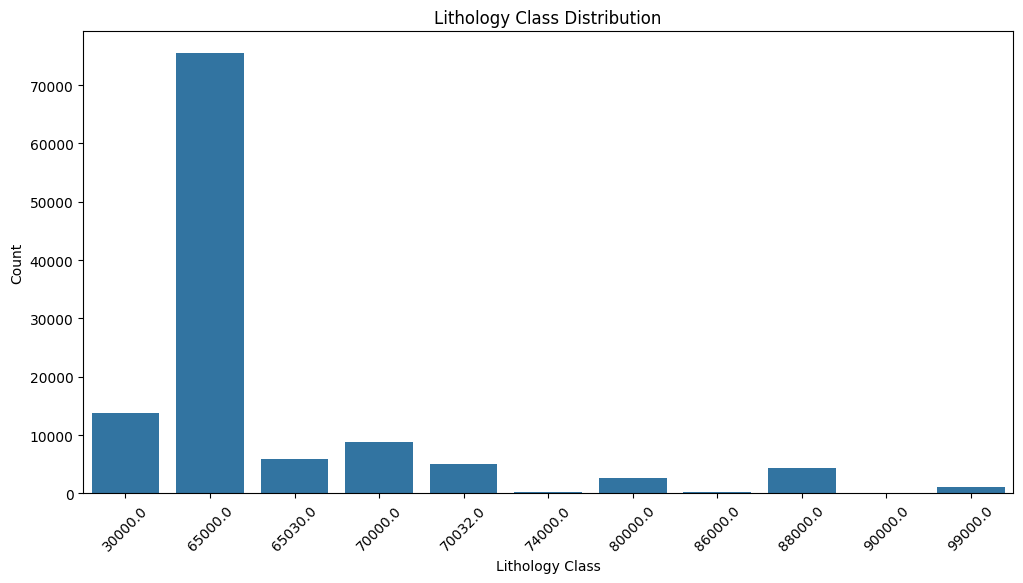

In [ ]:
#Visualizing lithology class distribution
plt.figure(figsize=(12, 6))
sns.countplot(x=df_cleaned['FORCE_2020_LITHOFACIES_LITHOLOGY'])
plt.xticks(rotation=45)
plt.title('Lithology Class Distribution')
plt.xlabel('Lithology Class')
plt.ylabel('Count')
plt.show()

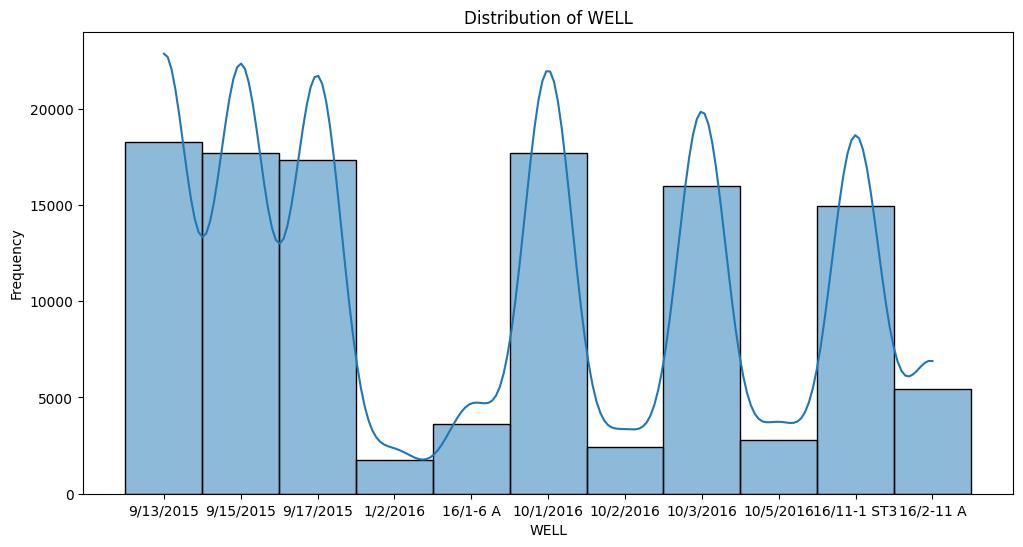

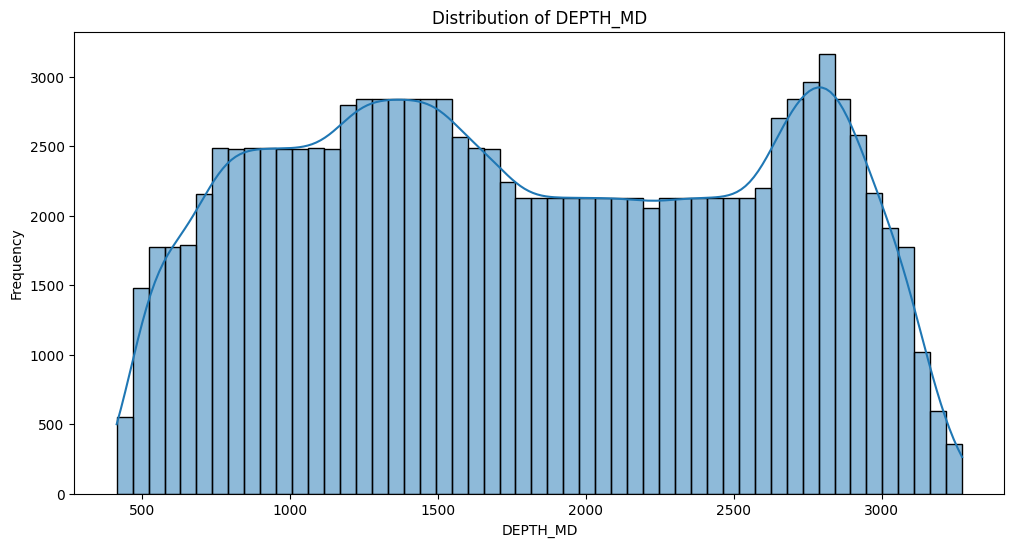

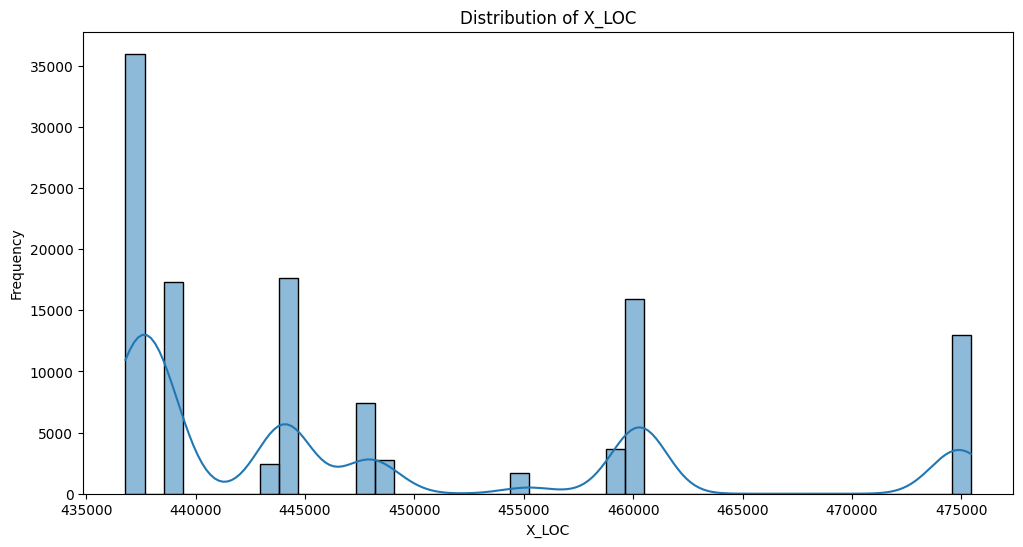

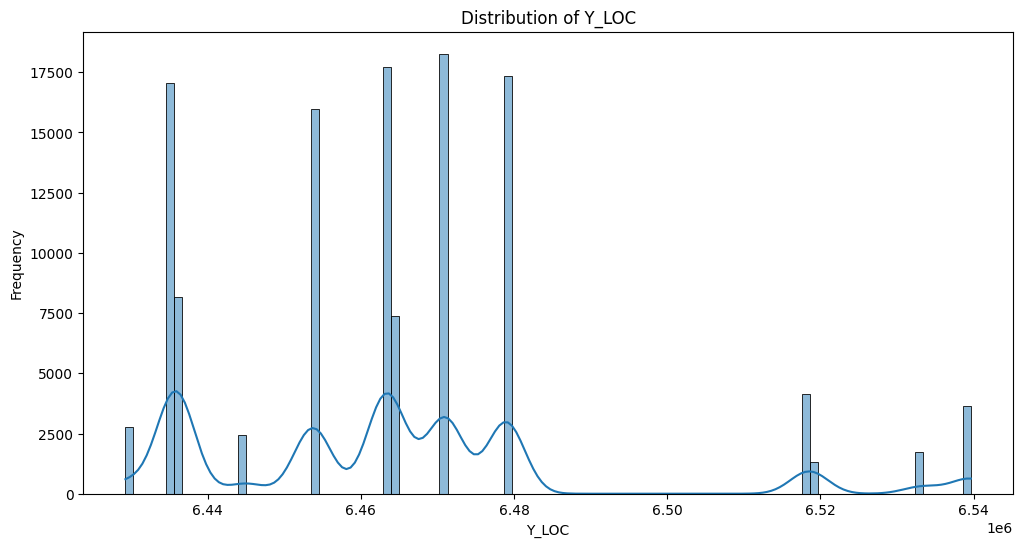

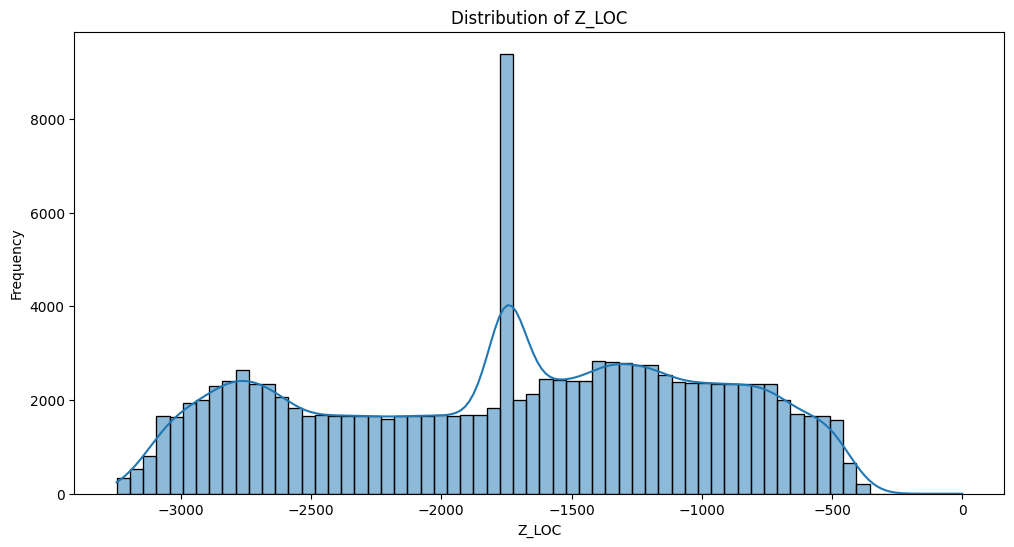

In [ ]:
selected_features = df_cleaned.columns[:5]
for feature in selected_features:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_cleaned, x=feature, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

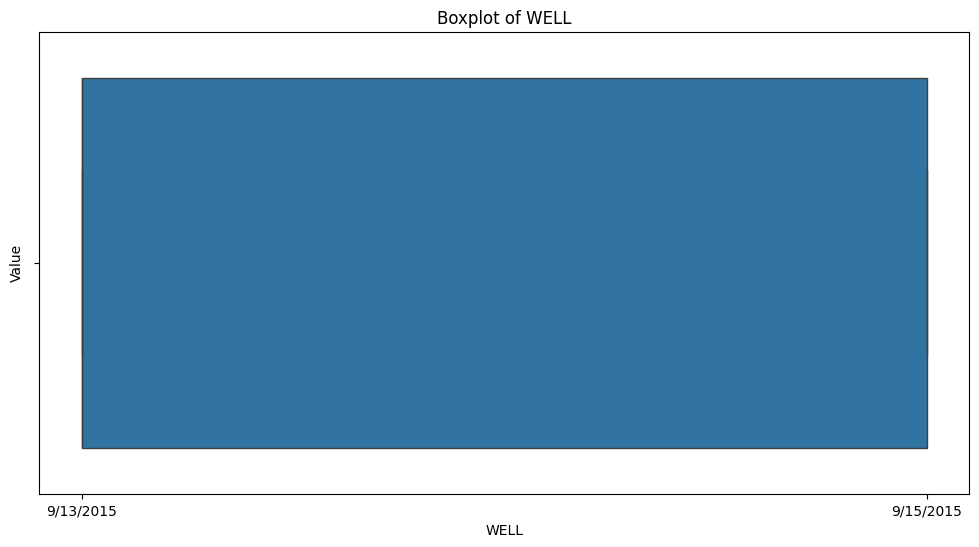

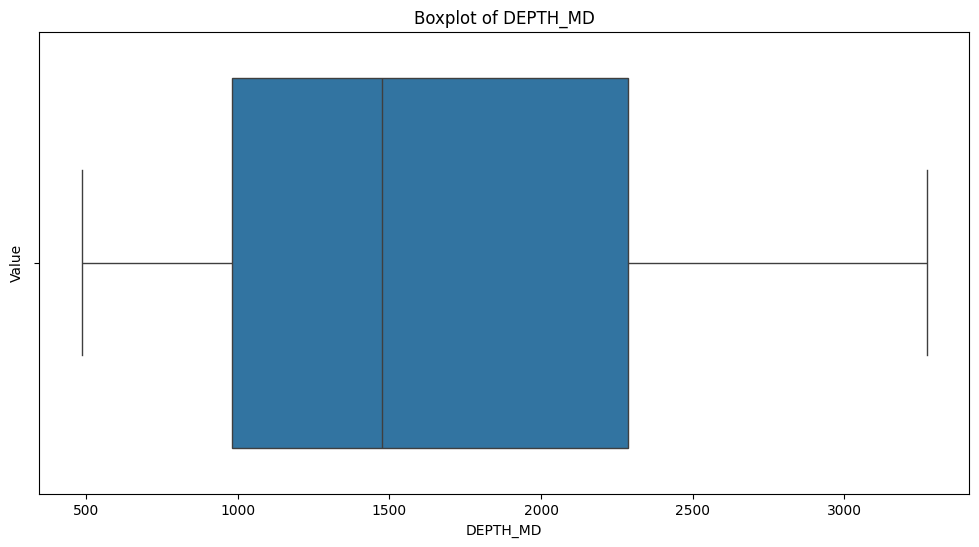

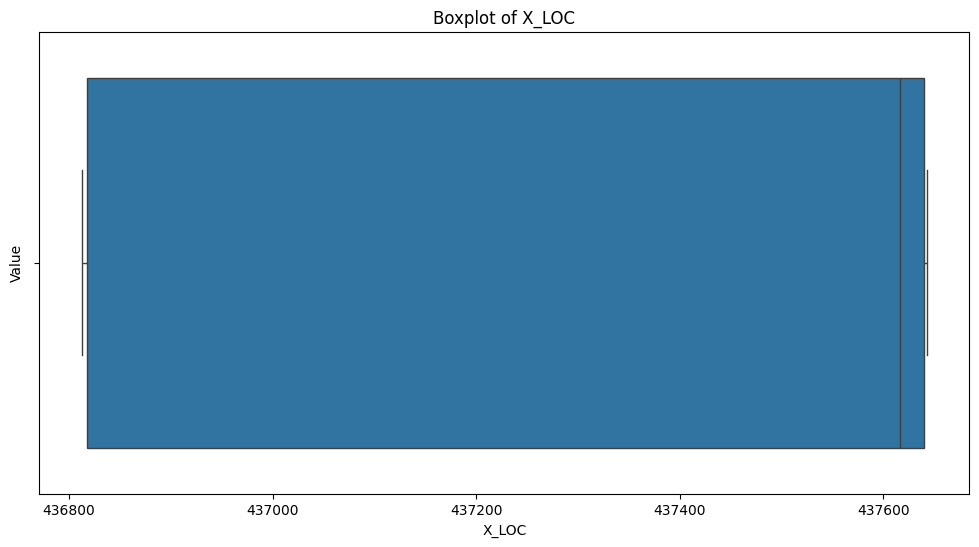

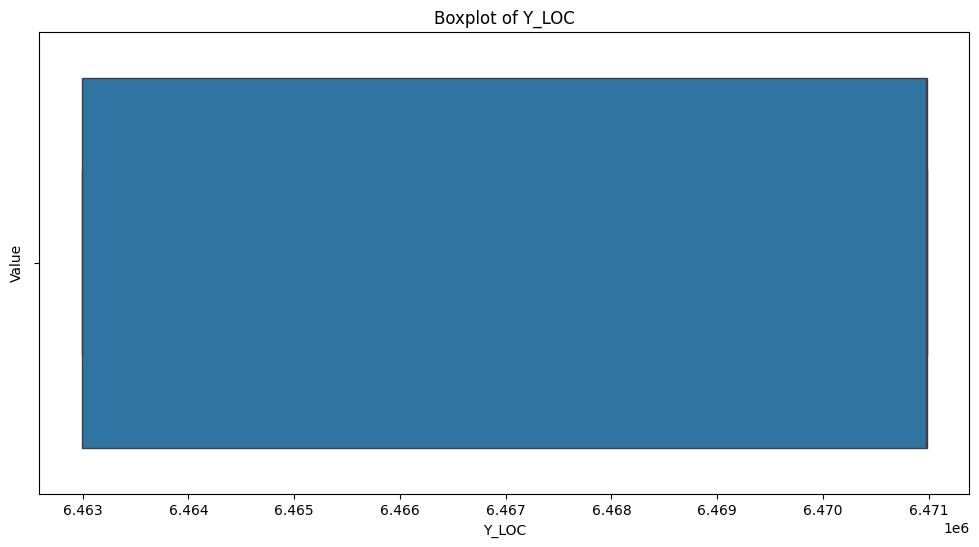

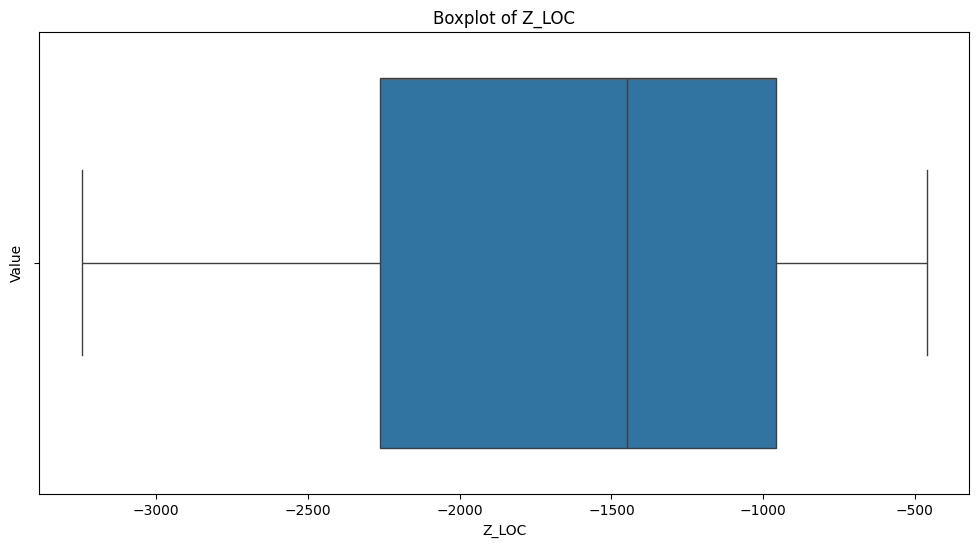

In [ ]:
#Boxplots to check for outliers in selected features
selected_features = df_cleaned.columns[:5]
for feature in selected_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=df_cleaned[feature])
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Value')
    plt.show()

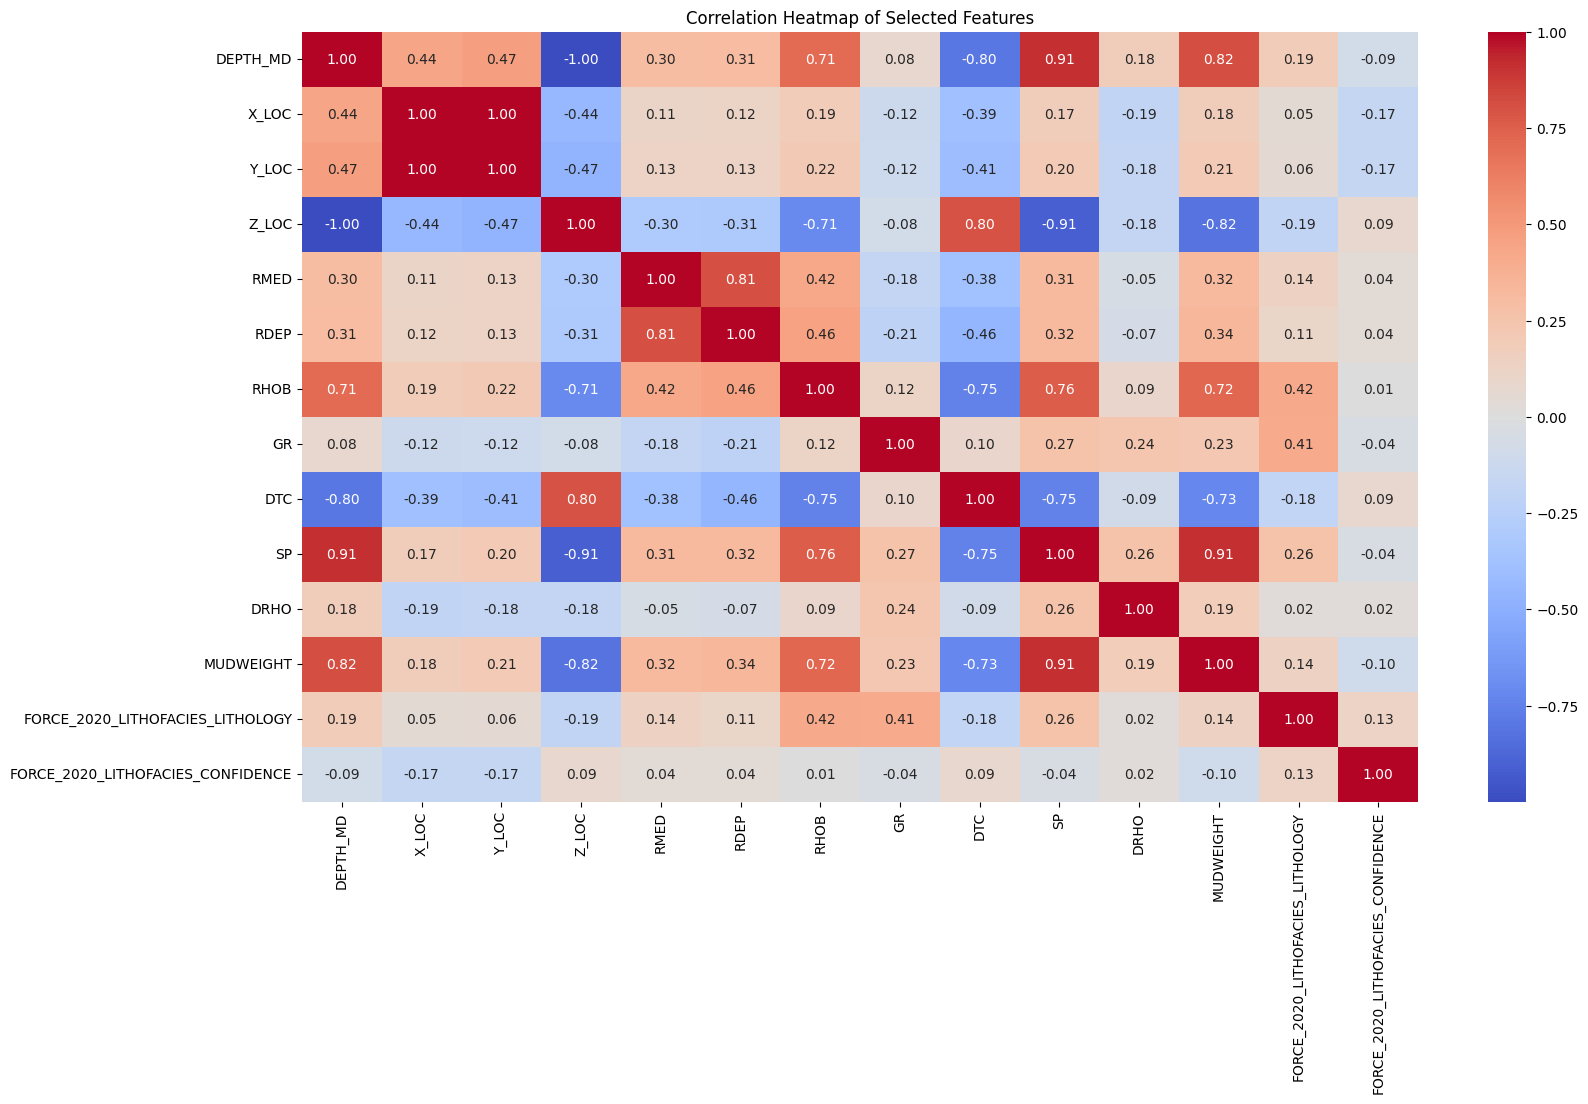

In [ ]:
#Correlation heatmap for selected features
plt.figure(figsize=(18, 10))
# Select only numerical features for correlation analysis
numerical_df = df_cleaned.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Features')
plt.show()

#Feature Selection
* Based on the correlation analysis and distrubtion plots, we will drop redundant featurs `Z_LOC (highly correlated with DEPTH_MD)`
* Keep strong predictors such as `DEPTH_MD, RHOB, GR,DTC,SP,MUDWEIGHT`


In [ ]:
df_sample= pd.read_csv('/content/cleaned_dataset.csv')
df_sample.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,9/13/2015,494.528,437641.9688,6470972.5,-469.501831,NORDLAND GP.,Missing,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0
1,9/13/2015,494.680,437641.9688,6470972.5,-469.653809,NORDLAND GP.,Missing,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0
2,9/13/2015,494.832,437641.9688,6470972.5,-469.805786,NORDLAND GP.,Missing,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0
3,9/13/2015,494.984,437641.9688,6470972.5,-469.957794,NORDLAND GP.,Missing,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0
4,9/13/2015,495.136,437641.9688,6470972.5,-470.109772,NORDLAND GP.,Missing,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0


In [ ]:
#drop redundant feature
drop_features = ['Z_LOC']
df_cleaned_drop = df_sample.drop(columns=drop_features)

In [ ]:
df_cleaned_drop.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,9/13/2015,494.528,437641.9688,6470972.5,NORDLAND GP.,Missing,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0
1,9/13/2015,494.680,437641.9688,6470972.5,NORDLAND GP.,Missing,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0
2,9/13/2015,494.832,437641.9688,6470972.5,NORDLAND GP.,Missing,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0
3,9/13/2015,494.984,437641.9688,6470972.5,NORDLAND GP.,Missing,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0
4,9/13/2015,495.136,437641.9688,6470972.5,NORDLAND GP.,Missing,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0


## Encoding Categorical Variables
* Convert `GROUP AND FORMATION` into numerical form using Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
categorical_columns = ['GROUP', 'FORMATION']

for column in categorical_columns:
    le = LabelEncoder()
    df_cleaned_drop[column] = le.fit_transform(df_cleaned_drop[column].astype(str))
    label_encoders[column] = le

In [ ]:
import numpy as np

#Function to check if a value is a date
def is_date(value):
  try:
    pd.to_datetime(value)
    return True
  except ValueError:
    return False


#Apply the function to detect date vs categorical well names
df_cleaned_drop['WELL_TYPE'] = df_cleaned_drop['WELL'].apply(lambda x: "date" if is_date(x) else "well_name")

#Separate date and categorical wells
date_wells = df_cleaned_drop[df_cleaned_drop['WELL_TYPE'] == 'date']["WELL"].unique()
categorical_wells = df_cleaned_drop[df_cleaned_drop['WELL_TYPE'] == 'well_name']["WELL"].unique()

In [ ]:
df_cleaned_drop.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,WELL_TYPE
0,9/13/2015,494.528,437641.9688,6470972.5,5,16,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0,date
1,9/13/2015,494.680,437641.9688,6470972.5,5,16,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0,date
2,9/13/2015,494.832,437641.9688,6470972.5,5,16,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0,date
3,9/13/2015,494.984,437641.9688,6470972.5,5,16,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0,date
4,9/13/2015,495.136,437641.9688,6470972.5,5,16,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0,date


In [ ]:

#Convert dates to numeric timestamps and encode well names
df_cleaned_drop['WELL_TYPE'] = df_cleaned_drop['WELL'].apply(lambda x:pd.to_datetime(x).timestamp() if is_date(x) else x)


In [ ]:
df_cleaned_drop.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,WELL_TYPE
0,9/13/2015,494.528,437641.9688,6470972.5,5,16,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0,1442102400.0
1,9/13/2015,494.680,437641.9688,6470972.5,5,16,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0,1442102400.0
2,9/13/2015,494.832,437641.9688,6470972.5,5,16,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0,1442102400.0
3,9/13/2015,494.984,437641.9688,6470972.5,5,16,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0,1442102400.0
4,9/13/2015,495.136,437641.9688,6470972.5,5,16,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0,1442102400.0


In [ ]:
#Label Encode Well Names
le_well = LabelEncoder()
df_cleaned_drop.loc[df_cleaned_drop['WELL_TYPE'] == 'well_name','well'] = le_well.fit_transform(df_cleaned_drop[df_cleaned_drop["WELL_TYPE"]=="well_name"]["WELL"].astype(str))

In [ ]:
df_cleaned_drop.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,WELL_TYPE,well
0,9/13/2015,494.528,437641.9688,6470972.5,5,16,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0,1442102400.0,NaN
1,9/13/2015,494.680,437641.9688,6470972.5,5,16,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0,1442102400.0,NaN
2,9/13/2015,494.832,437641.9688,6470972.5,5,16,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0,1442102400.0,NaN
3,9/13/2015,494.984,437641.9688,6470972.5,5,16,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0,1442102400.0,NaN
4,9/13/2015,495.136,437641.9688,6470972.5,5,16,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0,1442102400.0,NaN


In [ ]:
#Drop helper column "WELL_TYPE" after processing
df_cleaned_drop.drop(columns=['WELL_TYPE'],inplace=True)

In [ ]:
new_df = df_cleaned_drop.drop(columns=['WELL'])

In [ ]:
new_df.head()

,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,well
0,494.528,437641.9688,6470972.5,5,16,1.611410,1.798681,1.884186,80.200851,161.131180,24.612379,-0.574928,0.15218,65000.0,1.0,NaN
1,494.680,437641.9688,6470972.5,5,16,1.618070,1.795641,1.889794,79.262886,160.603470,23.895531,-0.570188,0.15218,65000.0,1.0,NaN
2,494.832,437641.9688,6470972.5,5,16,1.626459,1.800733,1.896523,74.821999,160.173615,23.916357,-0.574245,0.15218,65000.0,1.0,NaN
3,494.984,437641.9688,6470972.5,5,16,1.621594,1.801517,1.891913,72.878922,160.149429,23.793688,-0.586315,0.15218,65000.0,1.0,NaN
4,495.136,437641.9688,6470972.5,5,16,1.602679,1.795299,1.880034,71.729141,160.128342,24.104078,-0.597914,0.15218,65000.0,1.0,NaN


### Data Spliting
* Split the dataset into Training Set `70%, 15% Validation and 15% Testing Set`

In [ ]:
# Impute missing values in the target variable (if any) before splitting
new_df['FORCE_2020_LITHOFACIES_LITHOLOGY'].fillna(new_df['FORCE_2020_LITHOFACIES_LITHOLOGY'].mode()[0])


,FORCE_2020_LITHOFACIES_LITHOLOGY
0,65000.0
1,65000.0
2,65000.0
3,65000.0
4,65000.0
...,...
117893,65000.0
117894,65000.0
117895,65000.0
117896,65000.0


In [ ]:
# Define target variable and features
from sklearn.model_selection import train_test_split
target_variable = 'FORCE_2020_LITHOFACIES_LITHOLOGY'
features = [col for col in new_df.columns if col != target_variable]

# Splitting dataset into Training (70%), Validation(15%) and Testing (15%)
X_train, X_temp, y_train, y_temp = train_test_split(new_df[features], new_df[target_variable], test_size=0.3, random_state=42, stratify=new_df[target_variable])

# Splitting remaining 30% into validation (15%) and Testing (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display dataset splits
split_sizes = {
    'Training Set': len(X_train),
    'Validation Set': len(X_val),
    'Testing Set': len(X_test)
}

# Show dataset split information
split_sizes

{'Training Set': 82528, 'Validation Set': 17685, 'Testing Set': 17685}

In [ ]:
X_train.shape

(82528, 15)

In [ ]:
X_train.head()

,DEPTH_MD,X_LOC,Y_LOC,GROUP,FORMATION,RMED,RDEP,RHOB,GR,DTC,SP,DRHO,MUDWEIGHT,FORCE_2020_LITHOFACIES_CONFIDENCE,well
60679,741.135790,444151.0625,6435549.5,5,16,1.133387,1.133795,2.153269,112.364830,151.392822,73.368195,0.003772,0.141395,1.0,NaN
102941,1505.841201,474569.4688,6436489.0,6,1,0.797839,0.692236,2.153269,21.416523,156.994308,53.580070,0.003772,1.162316,3.0,NaN
8337,1761.752000,437634.4375,6470978.5,3,30,0.770901,0.723876,1.978215,80.785255,147.388840,58.429558,0.002181,0.135404,1.0,NaN
58368,1677.123735,459501.0313,6539598.5,3,7,0.697324,0.679726,2.261422,61.693207,135.088180,70.282761,0.003772,0.173748,1.0,NaN
67891,1837.359790,444152.9688,6435554.5,3,30,0.768205,0.678654,2.080820,88.712311,144.192017,99.200172,0.010540,0.158171,1.0,NaN


## Data Normalization

In [ ]:
from sklearn.preprocessing import MinMaxScaler

#Initialize MinMax Scaler
scaler = MinMaxScaler()

#Apply scaling to numerical features (excluding categorical features and target variable)
numerical_features = [col for col in X_train.columns if col not in ["GROUP","FORMATION","WELL"]]


#Fit and transform the training data
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])


#Transform the validation and testing data using the same scaler
X_val[numerical_features] = scaler.transform(X_val[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])



/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [ ]:
from sklearn.impute import SimpleImputer

#Create Imputer
imputer = SimpleImputer(strategy='mean')
# Fit & Transform the training data (and apply to validation/test)
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['well']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['well']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['well']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


## Training Classifiers
 * Decision Tree
 * Random Forest
 * Multilayer Perceptron


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize models
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42,n_estimators=100)
multilayerp_model= MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

In [ ]:
#Train models
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#Training random forest
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
multilayerp_model.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

In [ ]:
y_predict_df = decision_tree_model.predict(X_val)
y_predict_rf = random_forest_model.predict(X_val)
y_predict_mlp = multilayerp_model.predict(X_val)

In [ ]:
#Evaluating models
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_df = accuracy_score(y_val, y_predict_df)
accuracy_rf = accuracy_score(y_val, y_predict_rf)
accuracy_mlp = accuracy_score(y_val, y_predict_mlp)

print(f"Decision Tree Accuracy: {accuracy_df}")
print(f"Random Forest Accuracy: {accuracy_rf}")
print(f"MlP Accuracy: {accuracy_mlp}")

Decision Tree Accuracy: 0.9444727169918009
Random Forest Accuracy: 0.9668080294034492
MlP Accuracy: 0.9324286118179248


In [ ]:
#classification reports
report_df = classification_report(y_val, y_predict_df)
report_rf = classification_report(y_val, y_predict_rf)
report_mlp = classification_report(y_val, y_predict_mlp)


print("Decision Tree Classification Report:")
print(report_df)

print("\nRandom Forest Classification Report:")
print(report_rf)

print("\nMLP Classification Report:")
print(report_mlp)

Decision Tree Classification Report:
              precision    recall  f1-score   support

     30000.0       0.92      0.92      0.92      2071
     65000.0       0.97      0.97      0.97     11317
     65030.0       0.75      0.75      0.75       884
     70000.0       0.89      0.88      0.88      1332
     70032.0       0.94      0.96      0.95       770
     74000.0       0.81      0.79      0.80        28
     80000.0       0.85      0.88      0.86       406
     86000.0       1.00      0.98      0.99        45
     88000.0       1.00      1.00      1.00       647
     90000.0       0.67      0.75      0.71         8
     99000.0       0.92      0.84      0.88       177

    accuracy                           0.94     17685
   macro avg       0.88      0.88      0.88     17685
weighted avg       0.94      0.94      0.94     17685


Random Forest Classification Report:
              precision    recall  f1-score   support

     30000.0       0.96      0.95      0.96      2071
   

In [ ]:
#Confusion Matrix
cm_df = confusion_matrix(y_val, y_predict_df)
cm_rf = confusion_matrix(y_val, y_predict_rf)
cm_mlp = confusion_matrix(y_val, y_predict_mlp)


## Visualizing the confusion matrix

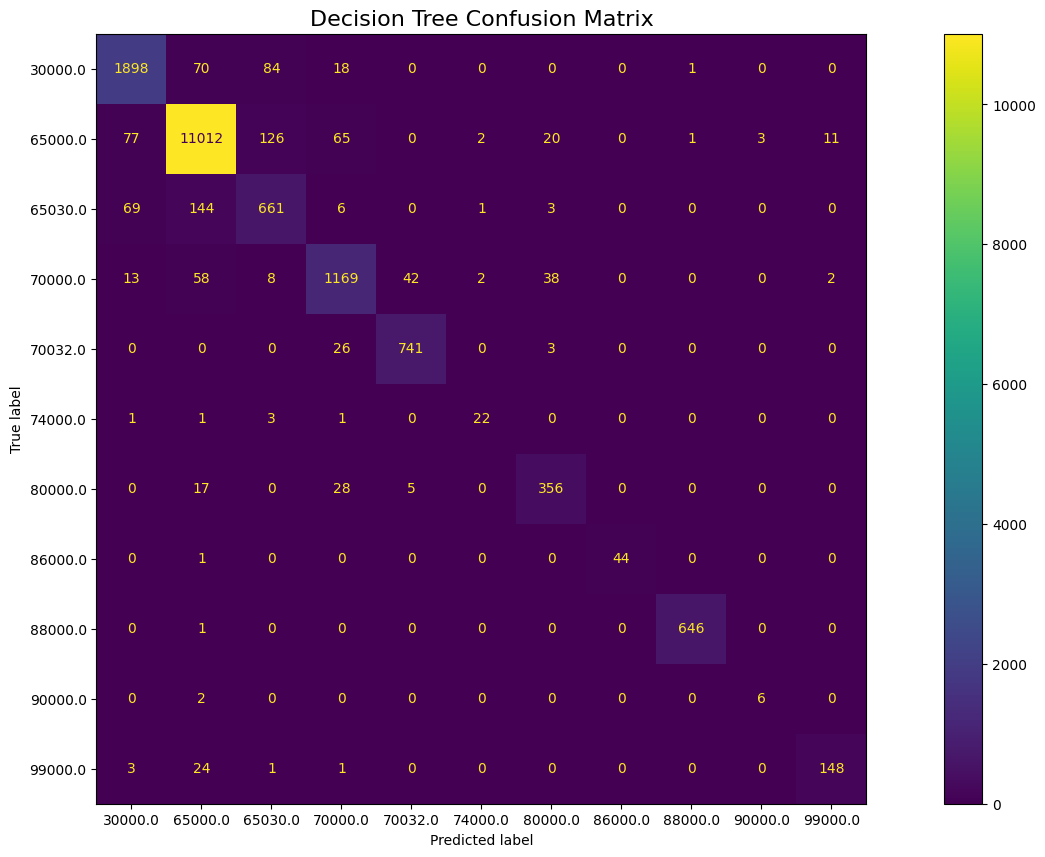

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create ConfusionMatrixDisplay objects
cm_display_df = ConfusionMatrixDisplay(confusion_matrix=cm_df, display_labels=np.unique(y_val))
cm_display_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=np.unique(y_val))
cm_display_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=np.unique(y_val))



fig, ax = plt.subplots(figsize=(20, 10)) # Create figure and axes with desired figsize
cm_display_df.plot(ax=ax) # Pass the axes object to the plot method
ax.set_title("Decision Tree Confusion Matrix", fontsize=16)
plt.show()



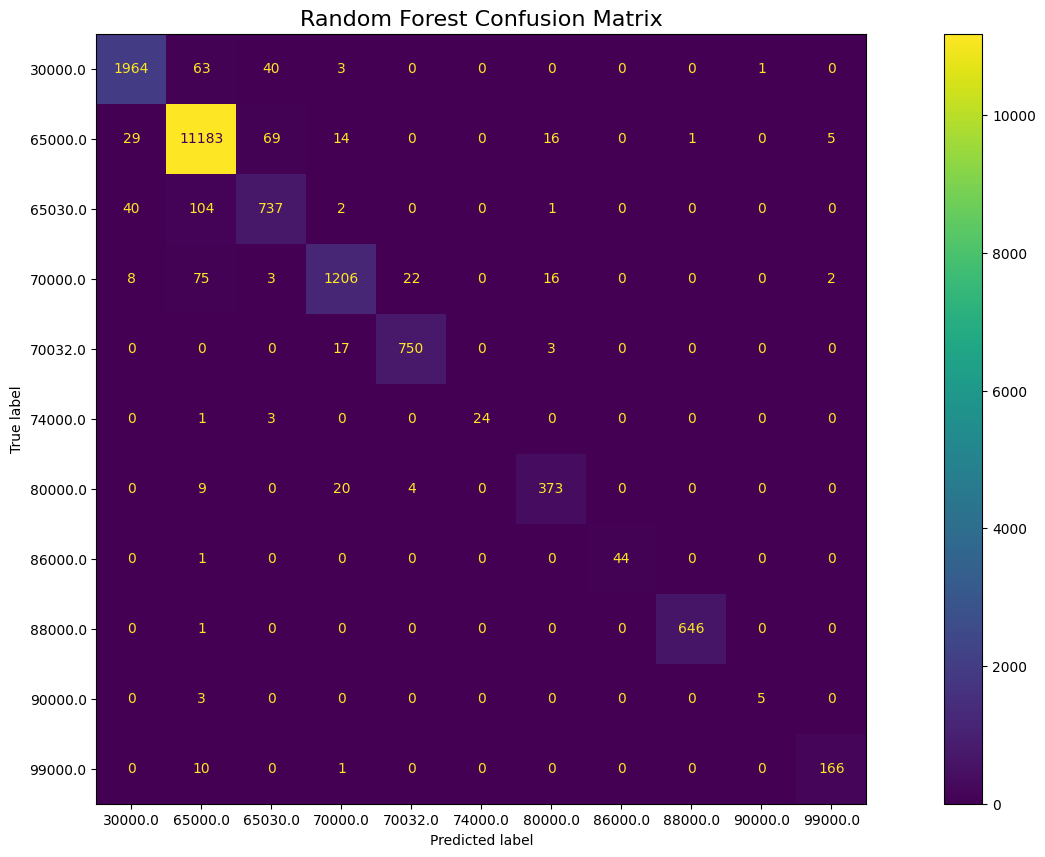

In [ ]:

fig, ax = plt.subplots(figsize=(20, 10))# Create figure and axes with desired figsize
cm_display_rf.plot(ax=ax)# Pass the axes object to the plot method
ax.set_title("Random Forest Confusion Matrix", fontsize=16)
plt.show()

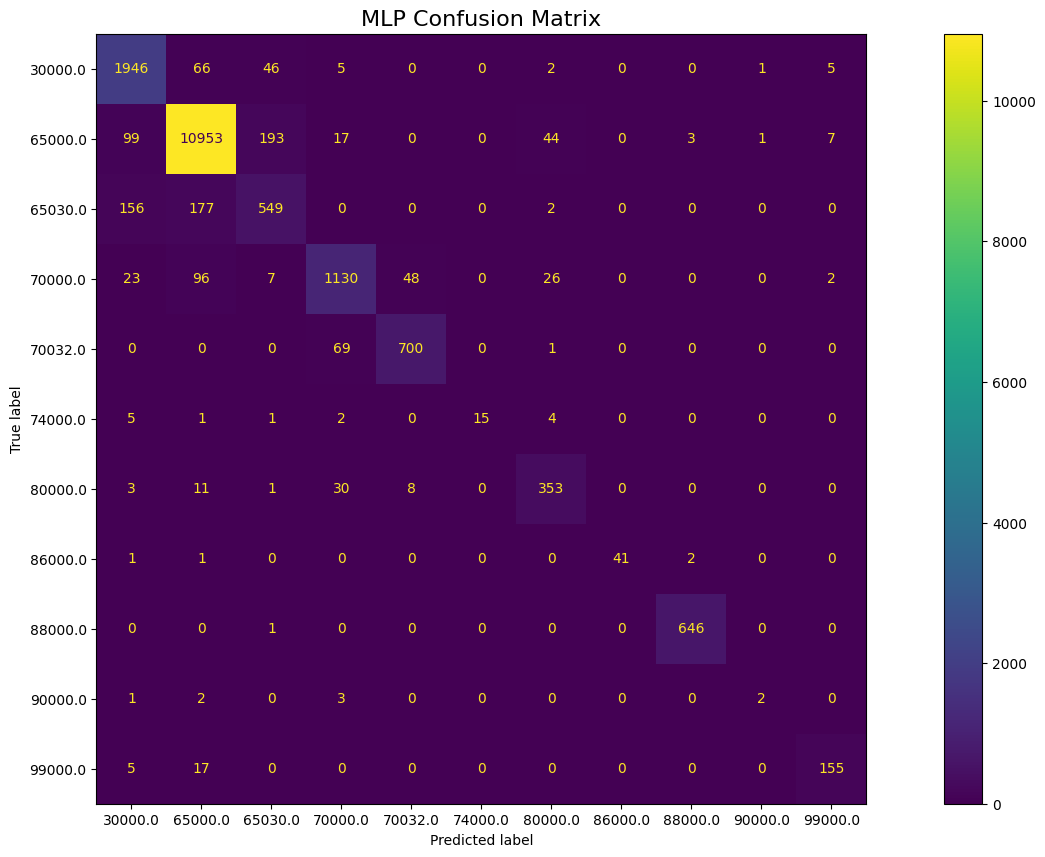

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))# Create figure and axes with desired figsize
cm_display_mlp.plot(ax=ax)# Pass the axes object to the plot method
ax.set_title("MLP Confusion Matrix", fontsize=16)
plt.show()

## Analysing Overfitting of the models
Using learning curve

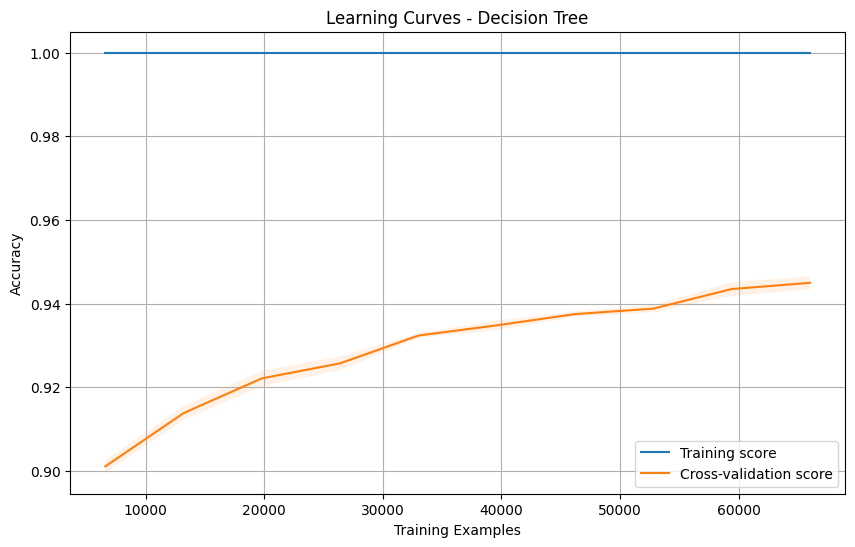

In [ ]:
from improved_models import plot_learning_curves

plot_learning_curves(decision_tree_model, X_train, y_train, "Decision Tree")




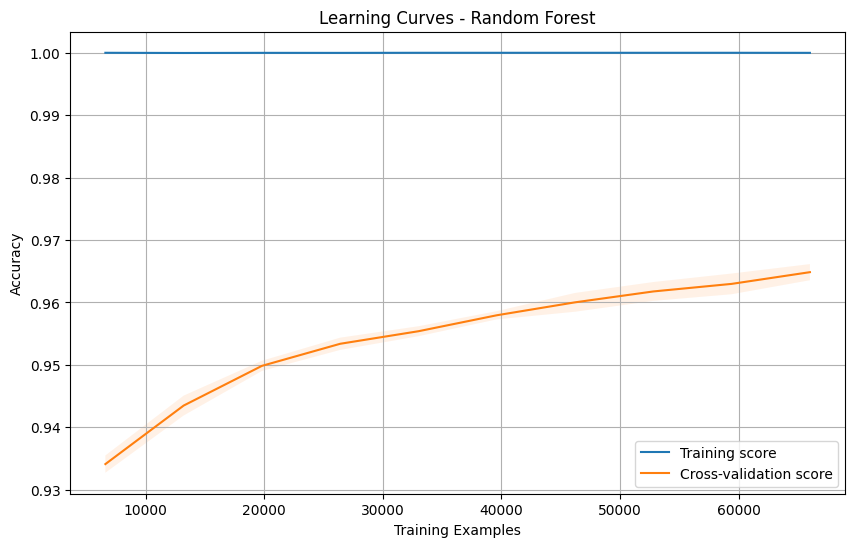

In [ ]:
plot_learning_curves(random_forest_model, X_train, y_train, "Random Forest")

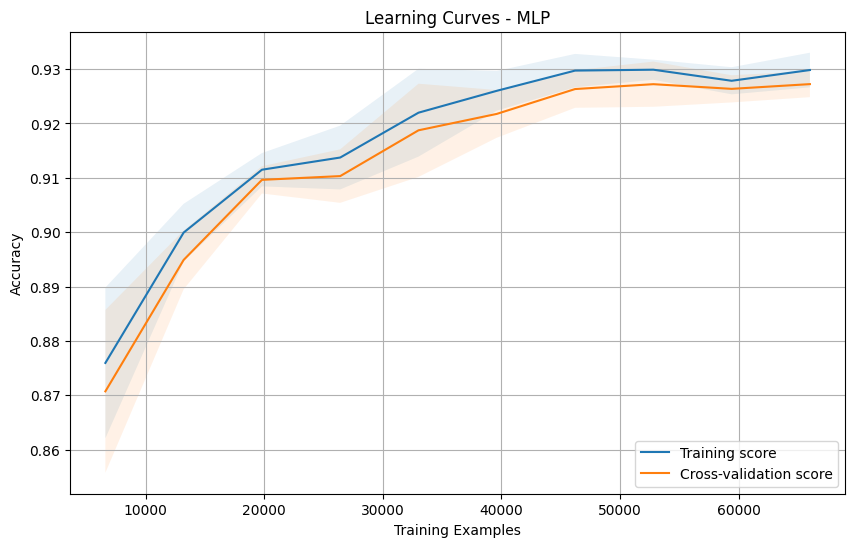

In [ ]:
plot_learning_curves(multilayerp_model, X_train, y_train, "MLP")

#Analysing and Improving the the models performance
from the above overfiting graphy I realized most of the decision tree and random forest were overfiting, thus learning everything on the training and not translating it to the validation set.The MLP on the hand shows that it too complex for the data and hence underfitting the data. I therefore improve the models with the following technics

* Cross-Validation (5 fold cross validation)
* Regularization (playing with hyperparameters)

In [ ]:
from improved_models import get_regularized_models, evaluate_model, plot_learning_curves, plot_feature_importance

# Create feature names
feature_names = [f'Feature_{i+1}' for i in range(X_train.shape[1])]

# Get the models
models = get_regularized_models()



Analyzing Decision Tree...
Decision Tree Cross-validation scores: [0.85556767 0.8258815  0.85756695 0.85822478 0.82902151]
Decision Tree Average CV score: 0.845 (+/- 0.029)


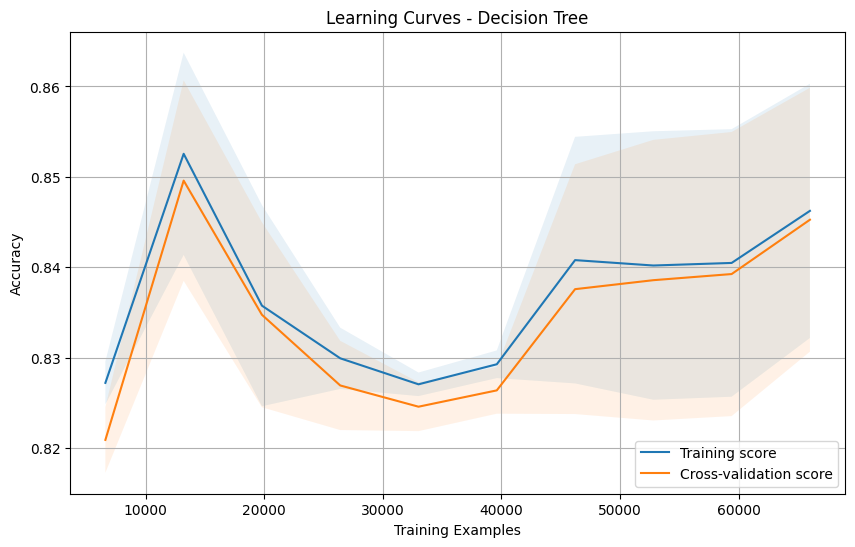

In [ ]:
# Analyze Decision Tree
print("\nAnalyzing Decision Tree...")
dt_model = models['Decision Tree']
dt_scores = evaluate_model(dt_model, X_train, y_train, "Decision Tree")
plot_learning_curves(dt_model, X_train, y_train, "Decision Tree")
plot_feature_importance(dt_model, feature_names, "Decision Tree")



Analyzing Random Forest...
Random Forest Cross-validation scores: [0.91809039 0.91693929 0.91839331 0.91663132 0.91584368]
Random Forest Average CV score: 0.917 (+/- 0.002)


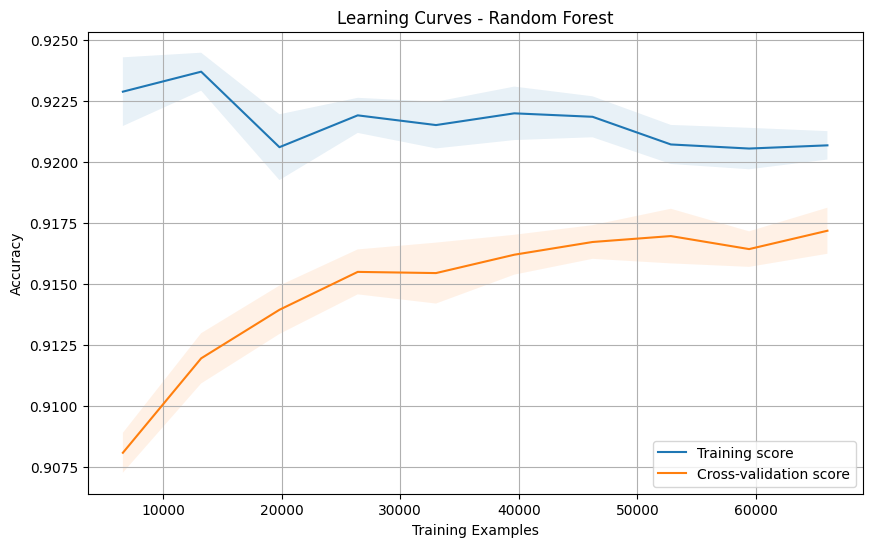

In [ ]:
# Analyze Random Forest
print("\nAnalyzing Random Forest...")
rf_model = models['Random Forest']
rf_scores = evaluate_model(rf_model, X_train, y_train, "Random Forest")
plot_learning_curves(rf_model, X_train, y_train, "Random Forest")
plot_feature_importance(rf_model, feature_names, "Random Forest")



Analyzing MLP...
MLP Cross-validation scores: [0.91815098 0.91251666 0.91633345 0.90596789 0.91747955]
MLP Average CV score: 0.914 (+/- 0.009)


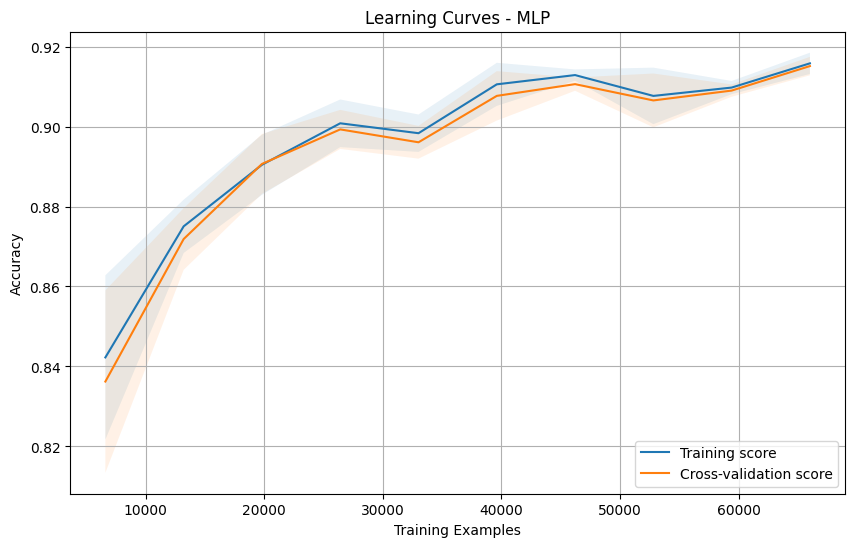

Feature importance plot not available for MLP


In [ ]:
# Analyze MLP
print("\nAnalyzing MLP...")
mlp_model = models['Neural Network']
mlp_scores = evaluate_model(mlp_model, X_train, y_train, "MLP")
plot_learning_curves(mlp_model, X_train, y_train, "MLP")
plot_feature_importance(mlp_model, feature_names, "MLP")

In [ ]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

def compare_models_roc_auc(models, X_test, y_test, model_names):
  """
  Compares models using ROC curves and AUC scores for multi-class classification.

  Args:
    models: A list of trained models.
    X_test: Test data features.
    y_test: Test data target variable.
    model_names: A list of model names corresponding to the models.

  Returns:
    None (displays ROC curves and prints AUC scores).
  """

  # Binarize the target variable for multi-class ROC
  y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
  n_classes = y_test_bin.shape[1]

  plt.figure(figsize=(10, 8))

  for model, model_name in zip(models, model_names):
    # Wrap the model with OneVsRestClassifier for multi-class ROC
    classifier = OneVsRestClassifier(model)
    y_score = classifier.fit(X_train, y_train).predict_proba(X_test)

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
      fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
      roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve for micro-average
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'{model_name} (AUC = {roc_auc["micro"]:.2f})',
             linestyle='-', linewidth=2)

  plt.plot([0, 1], [0, 1], 'k--', lw=2)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()

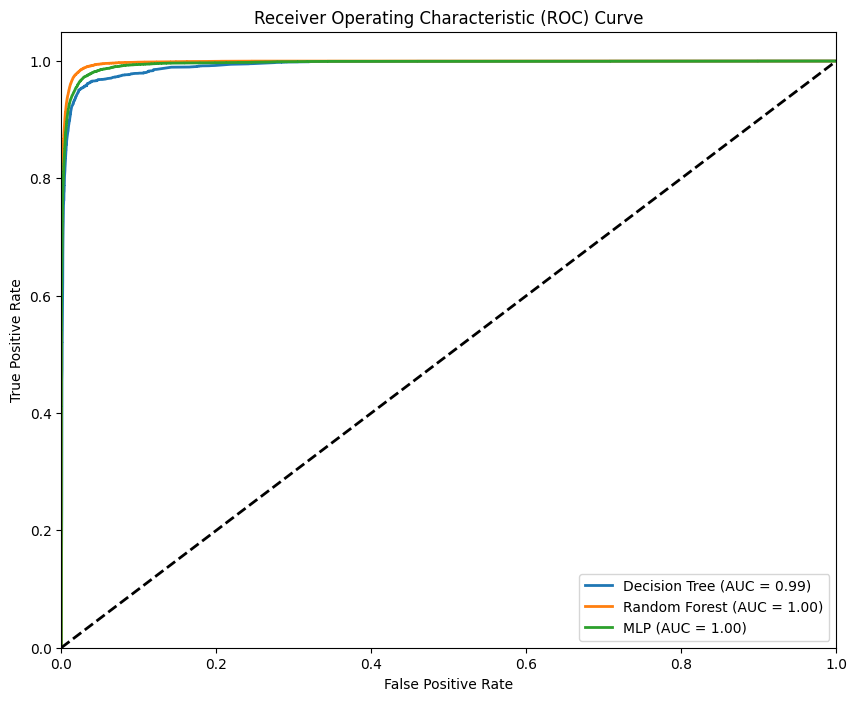

In [ ]:
compare_models_roc_auc(models=[dt_model, rf_model, mlp_model],
                       X_test=X_test,
                       y_test=y_test,
                       model_names=['Decision Tree', 'Random Forest', 'MLP'])